# Expand and Sparsify (mix\_100\_20\_1)

Kernel scatter plots (input vs output inner products) and linear SVM accuracy
for four 32-trace sensor expansions, swept over $p_{hd}$ and $d = k/N$.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from tools import load
from math import comb, sqrt, pi, exp
from scipy.integrate import quad
import torch

def backward_diff_array(y, h, n):
    """n-th backward finite difference (zero-padded to preserve length)."""
    coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h**n
    return np.concatenate([np.zeros(n), raw])

device = torch.device('mps' if torch.backends.mps.is_available() else
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [44]:
# Load data
filename = 'mix_100_20_1'
sensor_data, sequence, times_sec, sequence_sec = load(filename, reduced=True)
h = np.median(np.diff(times_sec))
n_sensors = sensor_data.shape[1]

# Labels
labels = np.zeros_like(times_sec)
for i in range(len(sequence_sec)):
    try:
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
    except IndexError:
        flag = (times_sec > sequence_sec[i])
    labels[flag] = int(sequence[i][1])

labeled_mask = labels > 0
y_labels = labels[labeled_mask].astype(int)
y_labels_0 = y_labels - 1
n_classes = int(y_labels_0.max()) + 1

print(f"Sensor data: {sensor_data.shape}  ({n_sensors} sensors)")
print(f"Labeled samples: {np.sum(labeled_mask)}")

Sensor data: (11445, 8)  (8 sensors)
Labeled samples: 11386


In [45]:
# Expansion helpers
def expand_with_derivatives(data, h, max_order):
    if max_order == 0:
        return data.copy()
    derivs = []
    for order in range(1, max_order + 1):
        d = np.apply_along_axis(
            lambda col: backward_diff_array(col, h, order), axis=0, arr=data)
        derivs.append(d)
    return np.hstack([data] + derivs)

# Pair pools
rng_pairs = np.random.default_rng(0)
all_ordered_pairs = [(i, j) for i in range(n_sensors) for j in range(n_sensors) if i != j]
ratio_pairs = [all_ordered_pairs[i] for i in rng_pairs.permutation(len(all_ordered_pairs))]
diff_pairs  = [all_ordered_pairs[i] for i in rng_pairs.permutation(len(all_ordered_pairs))]

# Building blocks
x_d1  = expand_with_derivatives(sensor_data, h, max_order=1)   # 16 cols
x_d12 = expand_with_derivatives(sensor_data, h, max_order=2)   # 24 cols
x_d123 = expand_with_derivatives(sensor_data, h, max_order=3)  # 32 cols
r8 = np.column_stack([sensor_data[:, i] / (sensor_data[:, j] + 1e-8) for i, j in ratio_pairs[:8]])
d8 = np.column_stack([sensor_data[:, i] - sensor_data[:, j] for i, j in diff_pairs[:8]])

# 4 configs (all 32 traces)
configs = {
    '∂¹+∂²+∂³':      x_d123,
    '∂¹+∂² + 8R':     np.hstack([x_d12, r8]),
    '∂¹+∂² + 8D':     np.hstack([x_d12, d8]),
    '∂¹ + 8R + 8D':   np.hstack([x_d1, r8, d8]),
}

for name, x in configs.items():
    print(f"{name}: {x.shape}")

∂¹+∂²+∂³: (11445, 32)
∂¹+∂² + 8R: (11445, 32)
∂¹+∂² + 8D: (11445, 32)
∂¹ + 8R + 8D: (11445, 32)


In [46]:
# Parameters
n_hd = 10_000
p_hd_sweep = [0.025, 0.05, 0.1, 0.2, 0.4, 0.6]
d_sweep = [0.025, 0.05, 0.1, 0.2, 0.4, 0.6]
n_pairs = 2000
n_repeats = 10


# Top-k kernel theory (from Top&bottom-k notebook)
def _phi(x):
    return (1.0 / sqrt(2.0 * pi)) * exp(-0.5 * x * x)

def K(r, s, n_terms=30):
    """Kernel for top-k selection via Mehler's Hermite series."""
    if not (0.0 < s < 1.0):
        raise ValueError("s must be in (0,1).")
    r = float(min(r, np.nextafter(1.0, 0.0)))
    r = max(r, np.nextafter(-1.0, 0.0))
    d = 1.0 - s
    t = float(norm.ppf(s))
    phi_t = _phi(t)
    a_prev = d
    a_curr = phi_t
    rn_nfact = 1.0
    result = rn_nfact * a_prev * a_prev
    for n in range(1, n_terms + 1):
        rn_nfact *= r / n
        result += rn_nfact * a_curr * a_curr
        a_next = t * a_curr - (n - 1) * a_prev
        a_prev = a_curr
        a_curr = a_next
    return result / d


# Linear SVM (Crammer-Singer on GPU)
def train_linear_svm(X, y, n_classes, C=1.0, lr=1e-3, n_epochs=200):
    n, dim = X.shape
    W = torch.zeros(n_classes, dim, device=device, requires_grad=True)
    b = torch.zeros(n_classes, device=device, requires_grad=True)
    opt = torch.optim.Adam([
        {'params': W, 'weight_decay': 1.0 / (C * n)},
        {'params': b, 'weight_decay': 0.0}
    ], lr=lr)
    idx = torch.arange(n, device=device)
    for _ in range(n_epochs):
        scores = X @ W.T + b
        correct_scores = scores[idx, y].unsqueeze(1)
        margins = scores - correct_scores + 1.0
        mask = torch.ones_like(scores)
        mask[idx, y] = 0.0
        loss = (torch.clamp(margins, min=0) * mask).sum() / n
        opt.zero_grad()
        loss.backward()
        opt.step()
    return W.detach(), b.detach()

@torch.no_grad()
def score_linear_svm(X, y, W, b):
    preds = (X @ W.T + b).argmax(dim=1)
    return (preds == y).float().mean().item()

In [47]:
import pickle, os

pkl_path = 'data/expand_sparsify_mix_results.pkl'
config_names = list(configs.keys())

if os.path.exists(pkl_path):
    with open(pkl_path, 'rb') as f:
        saved = pickle.load(f)
    cos_input  = saved['cos_input']
    cos_output = saved['cos_output']
    acc_table  = saved['acc_table']
    # Derive sweep values from actual keys (robust to metadata mismatch)
    _keys = list(cos_output.keys())
    p_hd_sweep = sorted(set(k[1] for k in _keys))
    d_sweep    = sorted(set(k[2] for k in _keys))
    print(f"Loaded results from {pkl_path}")
    print(f"  p_hd_sweep = {p_hd_sweep}")
    print(f"  d_sweep    = {d_sweep}")
else:
    # Compute inner products and accuracy for all configs × p_hd × d
    cos_input  = {}
    cos_output = {}
    acc_table  = {}

    y_t = torch.tensor(y_labels_0, dtype=torch.long, device=device)

    for cfg_name in config_names:
        x_dense = configs[cfg_name]
        n_dense = x_dense.shape[1]
        x_dense_t = torch.tensor(x_dense, dtype=torch.float32, device=device)

        n_samples = x_dense.shape[0]
        pair_idx = np.array([np.random.choice(n_samples, size=2, replace=False)
                             for _ in range(n_pairs)])
        i1 = torch.tensor(pair_idx[:, 0], device=device)
        i2 = torch.tensor(pair_idx[:, 1], device=device)
        v1 = x_dense_t[i1]
        v2 = x_dense_t[i2]
        cos_dense = (v1 * v2).sum(dim=1) / (v1.norm(dim=1) * v2.norm(dim=1))
        cos_input[cfg_name] = cos_dense.cpu().numpy()
        del v1, v2

        x_labeled = x_dense[labeled_mask]
        x_labeled_t = torch.tensor(x_labeled, dtype=torch.float32, device=device)

        for p in p_hd_sweep:
            for d in d_sweep:
                k = int(d * n_hd)

                W_hd = torch.bernoulli(torch.full((n_hd, n_dense), p, device=device))
                x_hd = x_dense_t @ W_hd.T
                _, topk_idx = torch.topk(x_hd, k, dim=1, largest=True)
                z_hd = torch.zeros_like(x_hd)
                z_hd.scatter_(1, topk_idx, 1.0)

                cos_hd = (z_hd[i1] * z_hd[i2]).sum(dim=1) / k
                cos_output[(cfg_name, p, d)] = cos_hd.cpu().numpy()
                del x_hd, z_hd, W_hd

                accs = []
                for seed in range(n_repeats):
                    torch.manual_seed(seed)
                    W_hd = torch.bernoulli(torch.full((n_hd, n_dense), p, device=device))
                    x_hd_lab = x_labeled_t @ W_hd.T
                    _, topk_idx = torch.topk(x_hd_lab, k, dim=1, largest=True)
                    z_hd_lab = torch.zeros_like(x_hd_lab)
                    z_hd_lab.scatter_(1, topk_idx, 1.0)

                    indices = np.arange(len(y_labels_0))
                    tr_idx, te_idx = train_test_split(
                        indices, test_size=0.2, random_state=seed, stratify=y_labels_0)
                    tr_idx = torch.tensor(tr_idx, device=device)
                    te_idx = torch.tensor(te_idx, device=device)

                    W, b = train_linear_svm(z_hd_lab[tr_idx], y_t[tr_idx], n_classes)
                    accs.append(score_linear_svm(z_hd_lab[te_idx], y_t[te_idx], W, b))
                    del W_hd, x_hd_lab, z_hd_lab

                acc_table[(cfg_name, p, d)] = (np.mean(accs), np.std(accs))
                print(f"{cfg_name}  p={p}  d={d:.2f}: acc={np.mean(accs):.4f} ± {np.std(accs):.4f}")

        del x_dense_t, x_labeled_t

Loaded results from data/expand_sparsify_mix_results.pkl
  p_hd_sweep = [0.025, 0.05, 0.1, 0.2, 0.4, 0.6]
  d_sweep    = [0.025, 0.05, 0.1, 0.2, 0.4, 0.6]


In [48]:
# Save results to pickle (delete the file to force re-computation)
with open(pkl_path, 'wb') as f:
    pickle.dump({
        'cos_input': cos_input,
        'cos_output': cos_output,
        'acc_table': acc_table,
        'config_names': config_names,
        'p_hd_sweep': p_hd_sweep,
        'd_sweep': d_sweep,
        'n_hd': n_hd,
        'n_pairs': n_pairs,
        'n_repeats': n_repeats,
    }, f)

print(f"Saved results to {pkl_path}")

Saved results to data/expand_sparsify_mix_results.pkl


/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_29378/2779974496.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


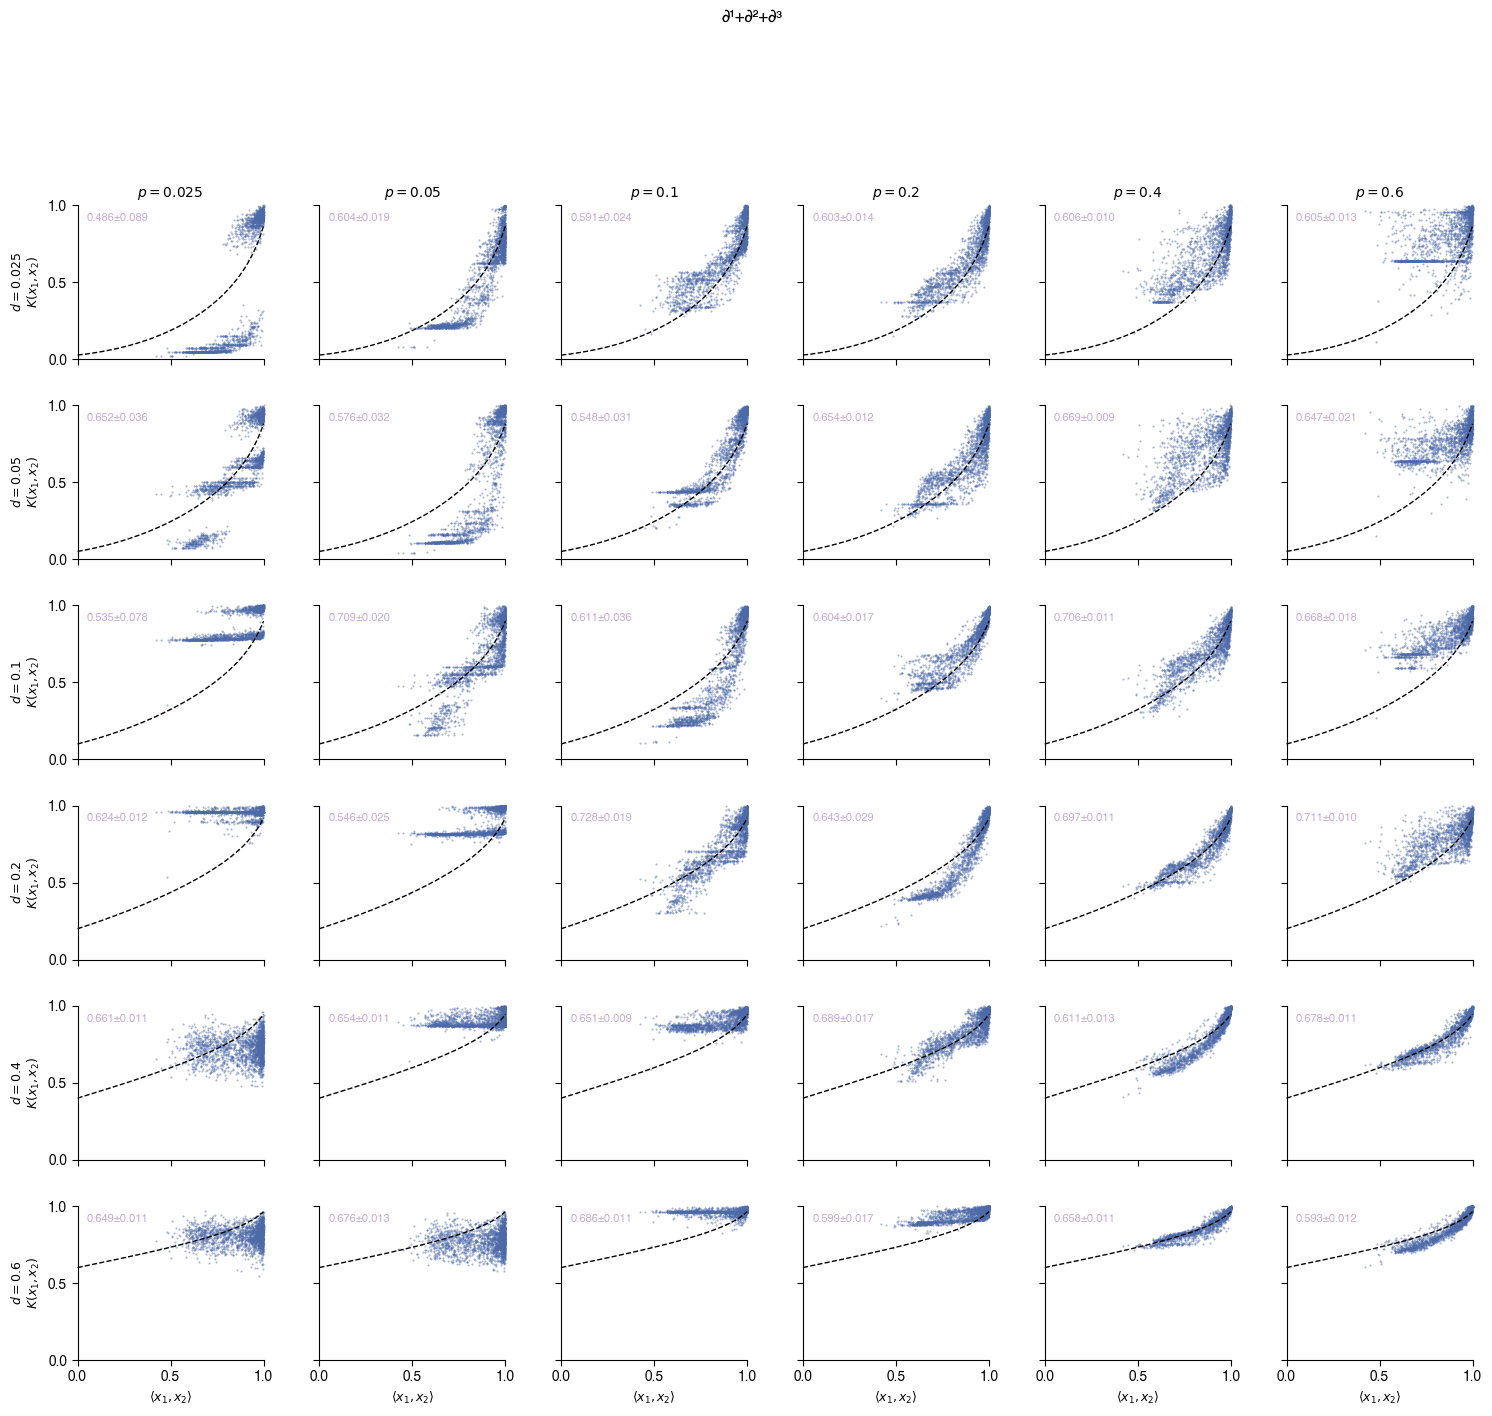

/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_29378/2779974496.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


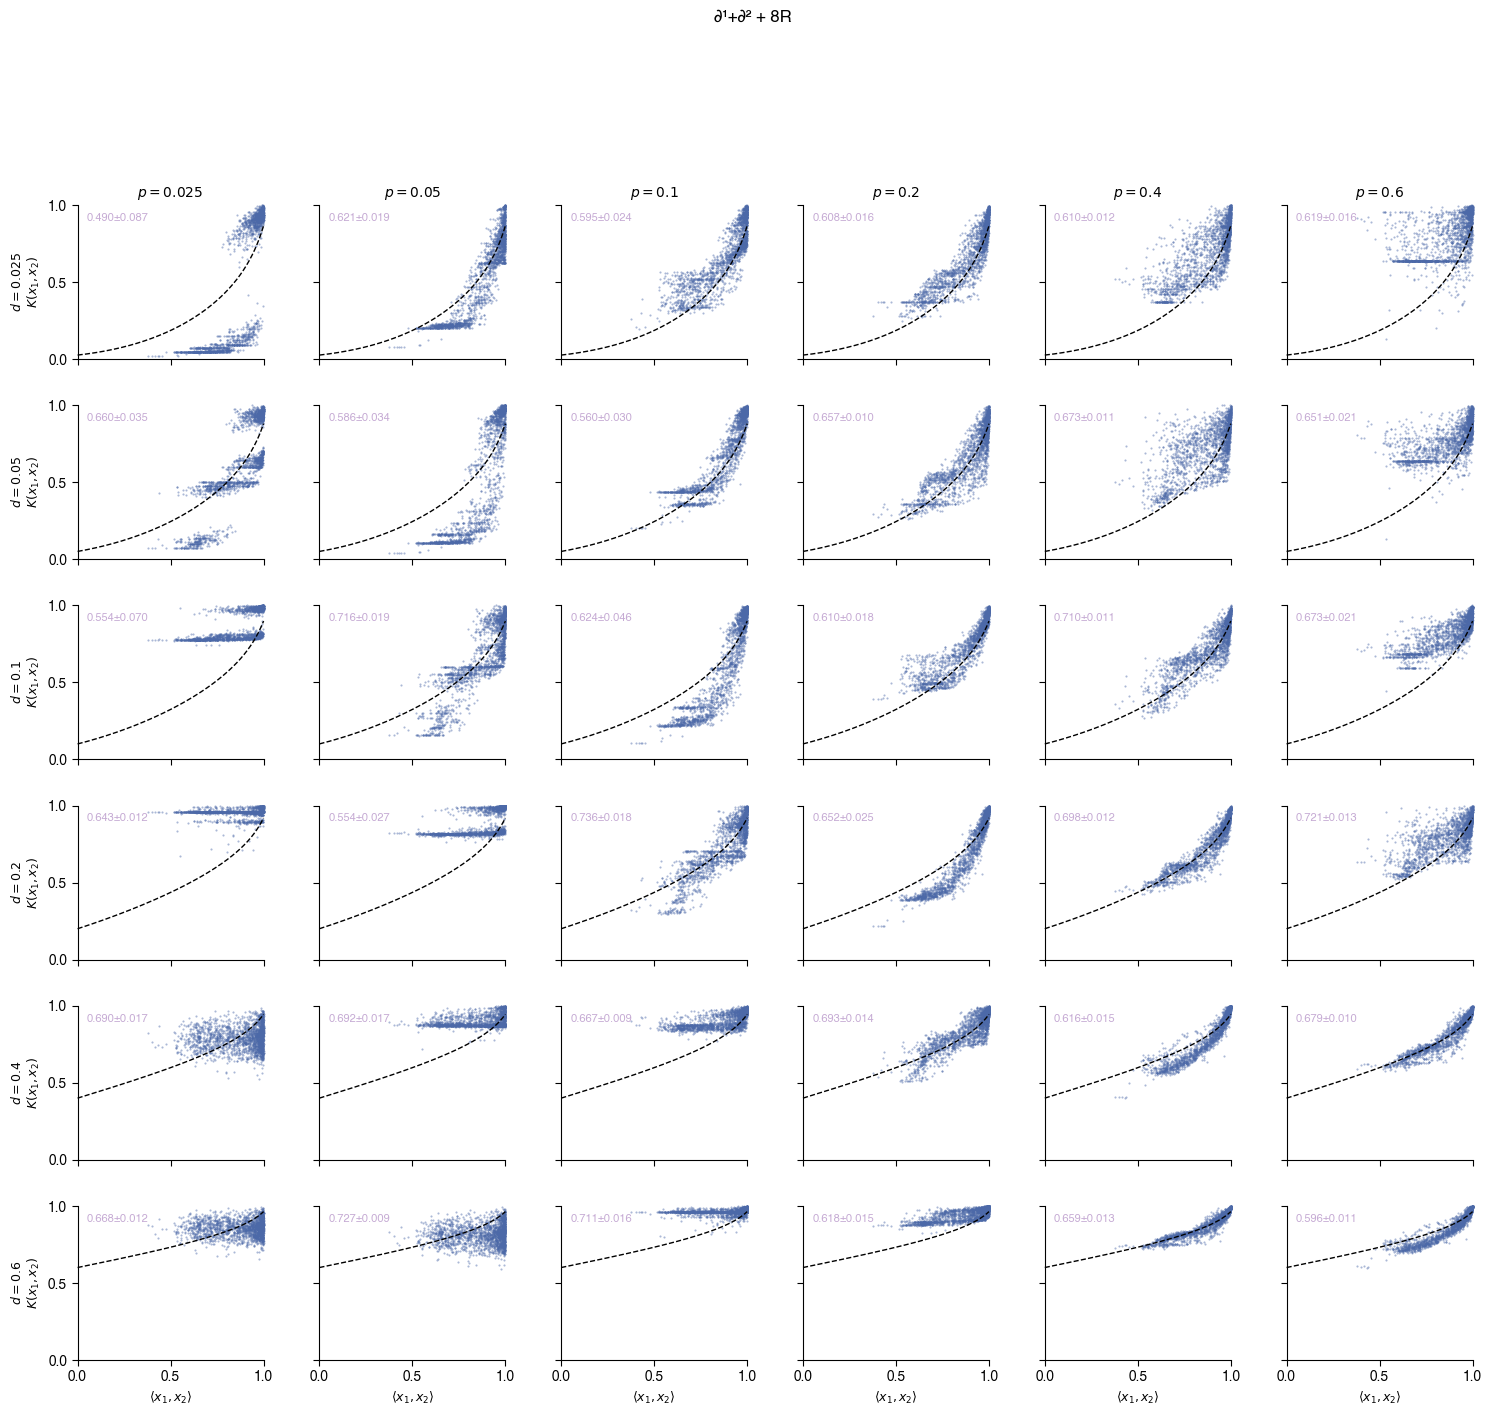

/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_29378/2779974496.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


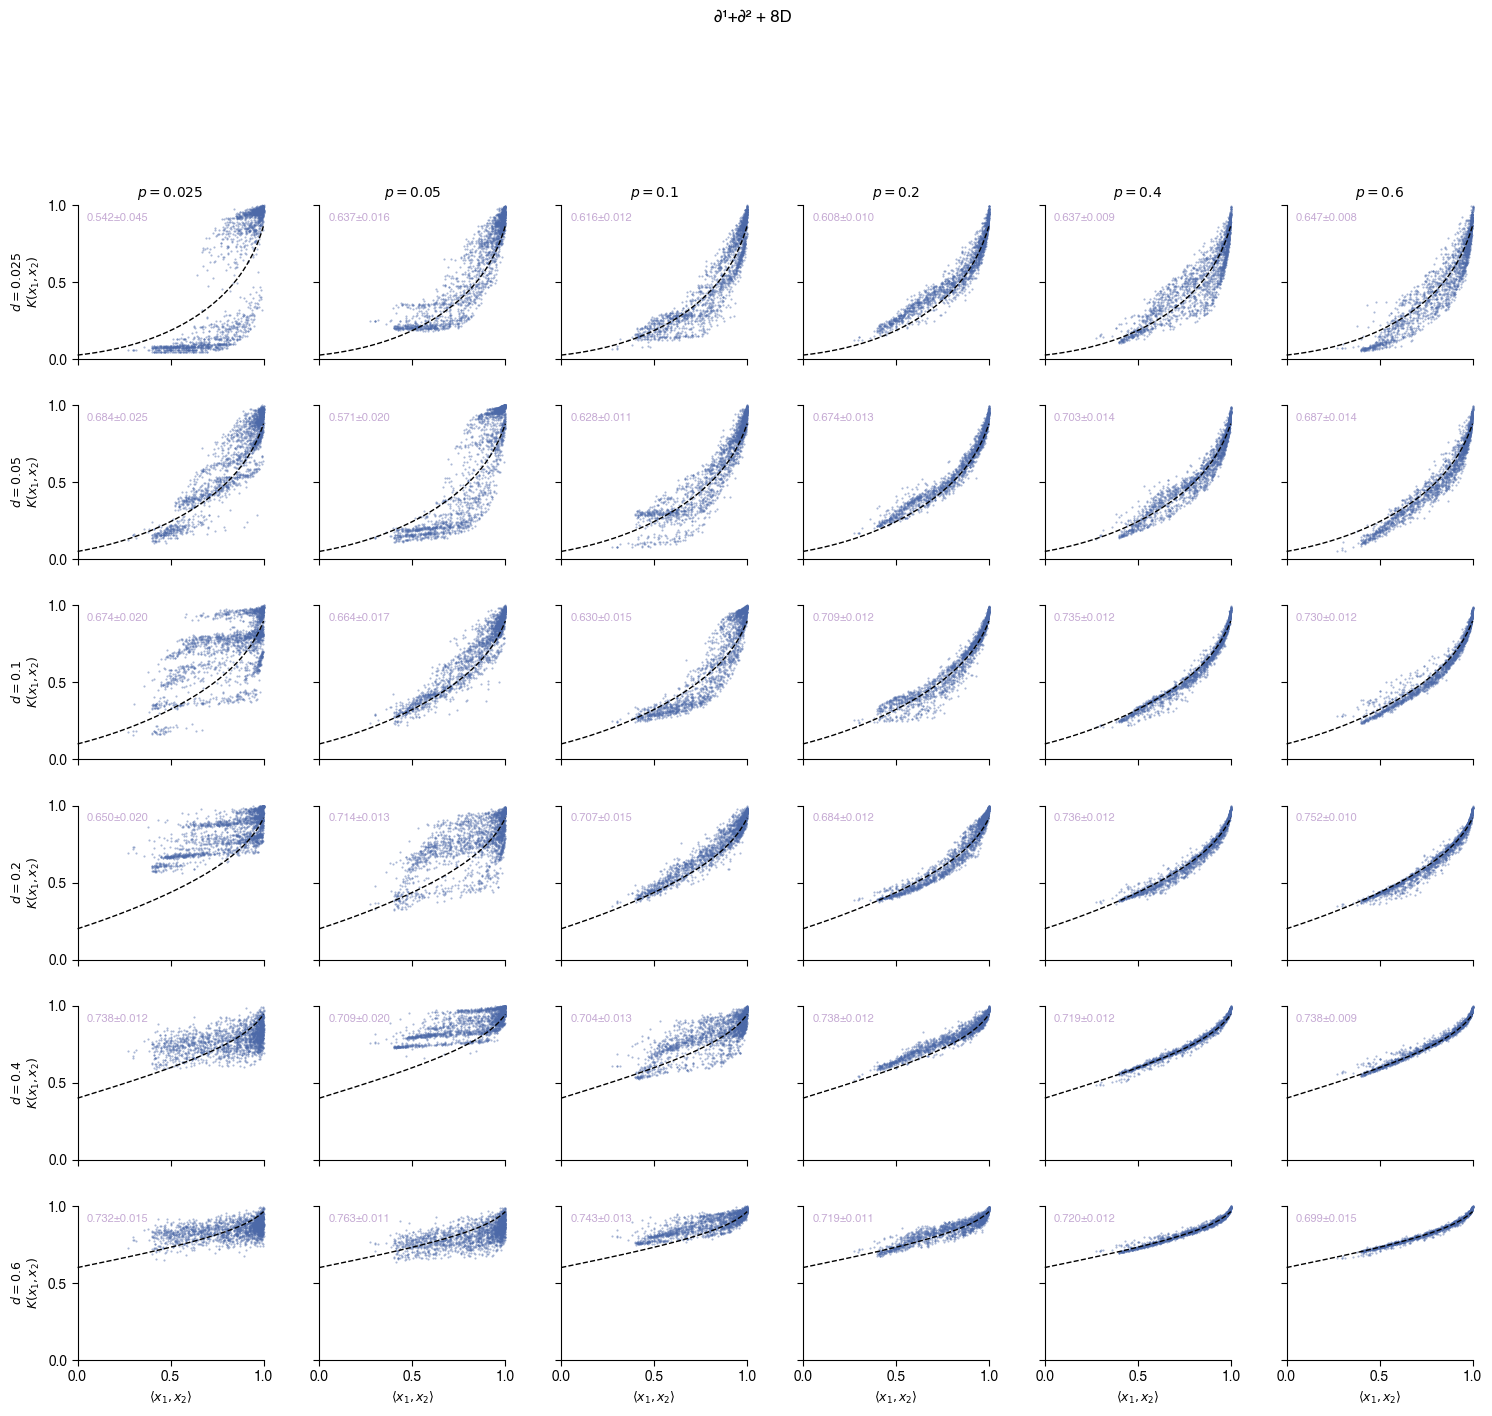

/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_29378/2779974496.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


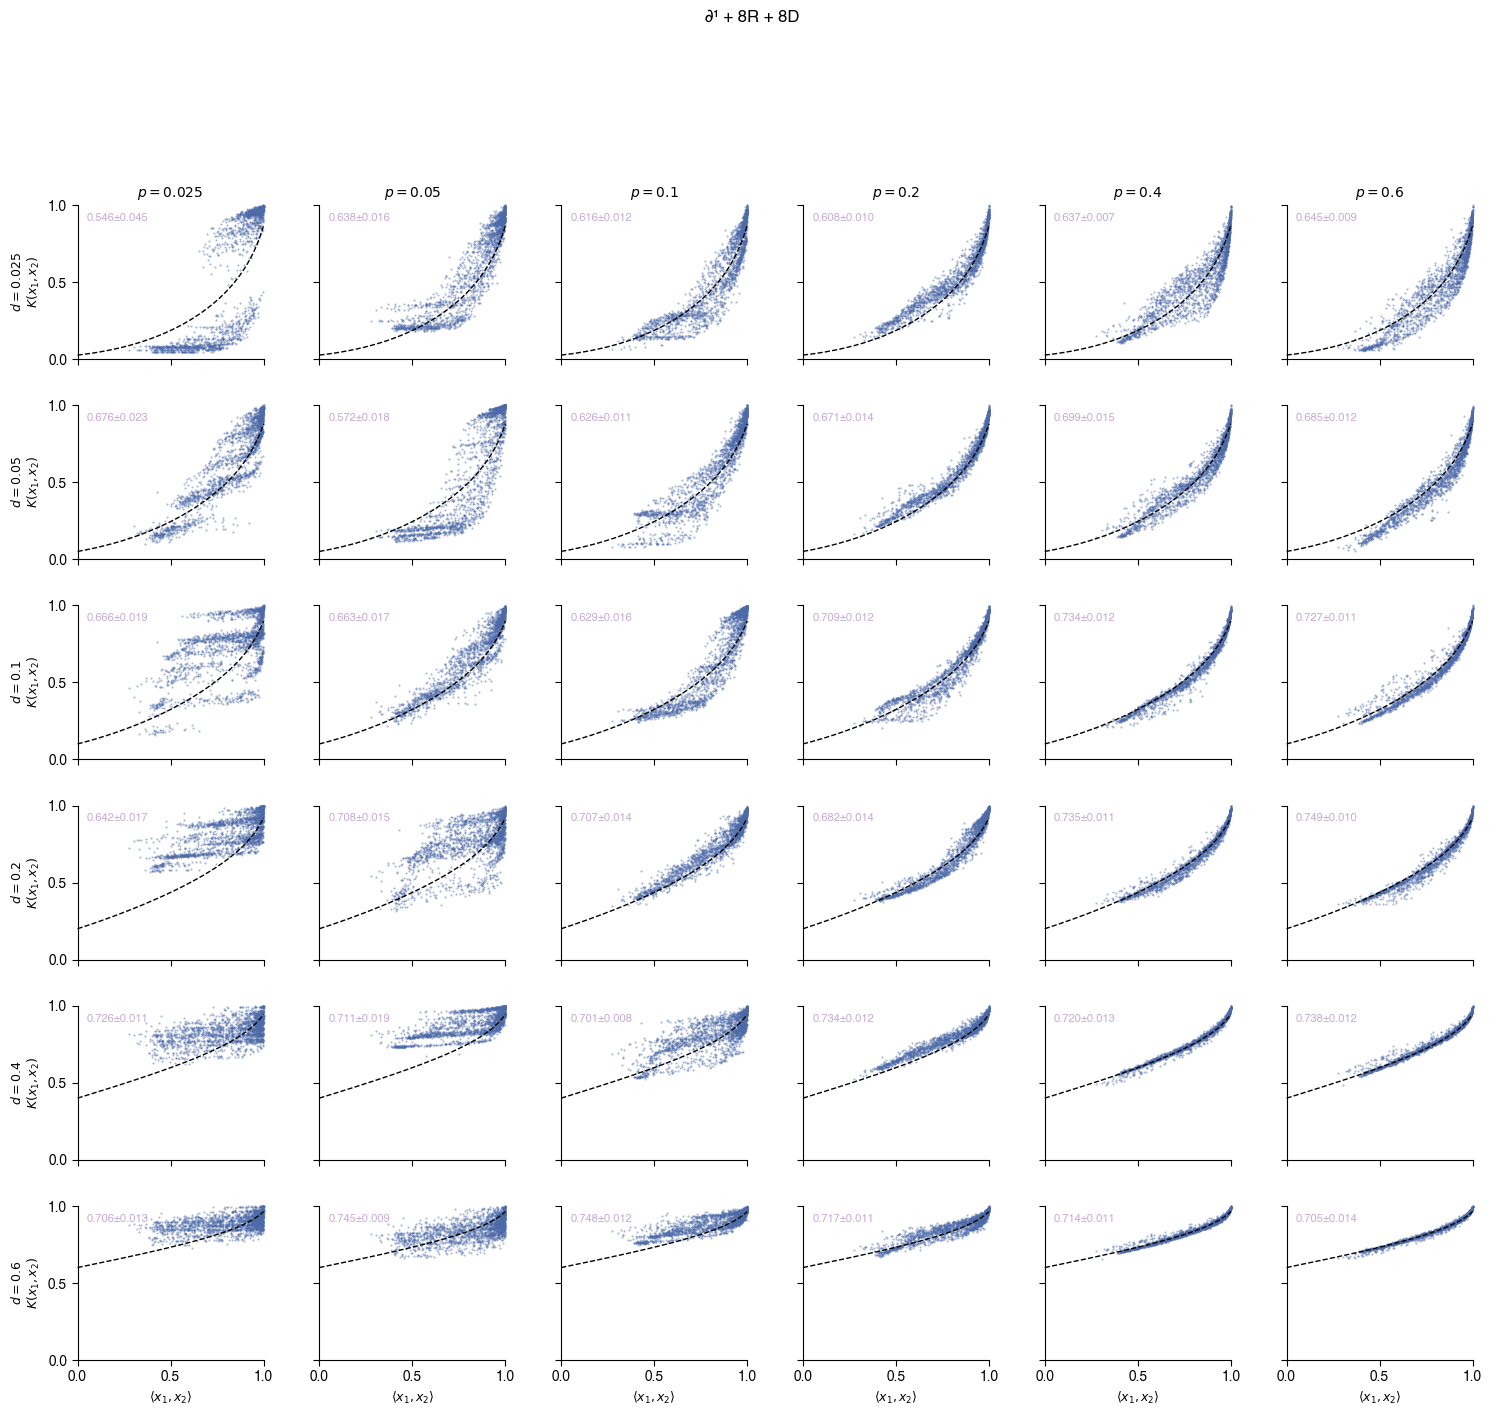

In [49]:
# Scatter plots: input vs output inner products (one figure per config)
# Rows = d, Columns = p_hd
rs_theory = np.linspace(0, 0.9999, 500)

for cfg_name in config_names:
    fig, axes = plt.subplots(len(d_sweep), len(p_hd_sweep),
                             figsize=(3 * len(p_hd_sweep), 2.5 * len(d_sweep)),
                             gridspec_kw={'wspace': 0.3, 'hspace': 0.3})

    for i, d in enumerate(d_sweep):
        s = 1 - d
        K_theory = np.clip([K(r=ri, s=s) for ri in rs_theory], 0, 1)

        for j, p in enumerate(p_hd_sweep):
            ax = axes[i, j]

            x = cos_input[cfg_name]
            y = cos_output[(cfg_name, p, d)]

            ax.plot(x, y, '.', alpha=0.5, ms=1, clip_on=False, color='C0')
            ax.plot(rs_theory, K_theory, '--', color='black', linewidth=1., clip_on=False)

            # Accuracy annotation (top left)
            m, sd = acc_table[(cfg_name, p, d)]
            ax.text(0.05, 0.95, f'{m:.3f}±{sd:.3f}',
                    transform=ax.transAxes, ha='left', va='top', fontsize=8,
                    color='C3', fontweight='bold')

            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.set_xticks([0, 0.5, 1]); ax.set_yticks([0, 0.5, 1])

            # Column headers
            if i == 0:
                ax.set_title(f'$p = {p}$', fontsize=10)

            # Row labels
            if j == 0:
                ax.set_ylabel(f'$d={d}$\n' + r'$K(x_1, x_2)$', fontsize=9)
            else:
                ax.set_yticklabels([])

            # x-labels only on bottom row
            if i == len(d_sweep) - 1:
                ax.set_xlabel(r'$\langle x_1, x_2 \rangle$', fontsize=9)
            else:
                ax.set_xticklabels([])

    fig.suptitle(cfg_name, fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

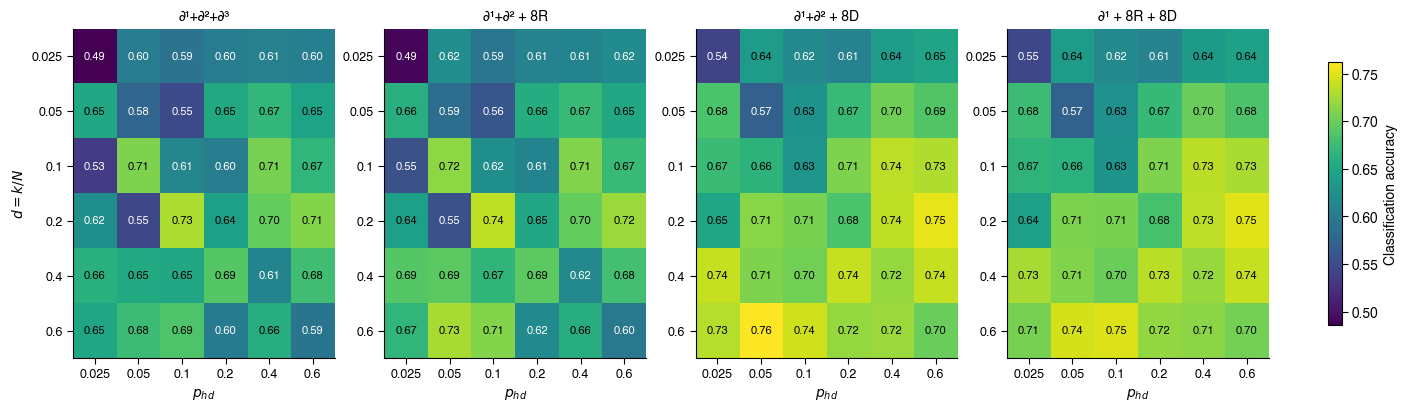

In [50]:
# Accuracy heatmaps: one per config, p_hd on x-axis, d on y-axis
fig, axes = plt.subplots(1, len(config_names), figsize=(3.5 * len(config_names), 4),
                         constrained_layout=True)

# Build accuracy matrix for global colorbar limits
all_means = []
for cfg_name in config_names:
    for p in p_hd_sweep:
        for d in d_sweep:
            all_means.append(acc_table[(cfg_name, p, d)][0])
vmin, vmax = min(all_means), max(all_means)

for ci, cfg_name in enumerate(config_names):
    ax = axes[ci]

    # Build matrix: rows = d (top to bottom = large to small d), cols = p
    mat = np.zeros((len(d_sweep), len(p_hd_sweep)))
    annot = np.empty_like(mat, dtype=object)
    for i, d in enumerate(d_sweep):
        for j, p in enumerate(p_hd_sweep):
            m, s = acc_table[(cfg_name, p, d)]
            mat[i, j] = m
            annot[i, j] = f'{m:.2f}'

    im = ax.imshow(mat, aspect='auto', vmin=vmin, vmax=vmax, cmap='viridis',
                   origin='upper')

    # Annotate cells
    for i in range(len(d_sweep)):
        for j in range(len(p_hd_sweep)):
            color = 'white' if mat[i, j] < (vmin + vmax) / 2 else 'black'
            ax.text(j, i, annot[i, j], ha='center', va='center',
                    fontsize=8, color=color)

    ax.set_xticks(range(len(p_hd_sweep)))
    ax.set_xticklabels([f'{p}' for p in p_hd_sweep], fontsize=9)
    ax.set_xlabel('$p_{hd}$')

    ax.set_yticks(range(len(d_sweep)))
    ax.set_yticklabels([f'{d}' for d in d_sweep], fontsize=9)
    if ci == 0:
        ax.set_ylabel('$d = k/N$')

    ax.set_title(cfg_name, fontsize=10)

fig.colorbar(im, ax=axes, label='Classification accuracy', shrink=0.8)
plt.show()